# KKBox Churn Prediction — Model Comparison

Rewritten as a proper step-by-step notebook (original was one long cell). Logic is
unchanged from the source notebook; only structure, plus three compatibility fixes
for modern pandas/scikit-learn (noted inline where they occur).

**Note on data:** running on synthetic data matching the real v2 schema
(`train_v2.csv`, `transactions_v2.csv`, `user_logs_v2.csv`, `members_v3.csv`,
`sample_submission_v2.csv`) — real Kaggle access wasn't available. Swap in the real
files with the same names and every cell below runs unchanged.


## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

train = pd.read_csv('train_v2.csv')
sample_submission = pd.read_csv('sample_submission_v2.csv')
transactions = pd.read_csv('transactions_v2.csv')
user_logs = pd.read_csv('user_logs_v2.csv')
members = pd.read_csv('members_v3.csv')

# set the options so the output format can be displayed correctly
pd.set_option('expand_frame_repr', True)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

print(f"train: {train.shape}, transactions: {transactions.shape}, "
      f"user_logs: {user_logs.shape}, members: {members.shape}")

train: (4981, 2), transactions: (101337, 9), user_logs: (710533, 9), members: (20000, 6)


In [3]:
# check the number of duplicate accounts in each table
print('train duplicates:', train.duplicated('msno').sum())
print('sample_submission duplicates:', sample_submission.duplicated('msno').sum())
print('transactions duplicates:', transactions.duplicated('msno').sum())
print('user_logs duplicates:', user_logs.duplicated('msno').sum())
print('members duplicates:', members.duplicated('msno').sum())

train duplicates: 0
sample_submission duplicates: 0
transactions duplicates: 81337
user_logs duplicates: 690533
members duplicates: 0


## 2. Aggregate Transactions and User Logs to One Row per User

Both `transactions` and `user_logs` have multiple rows per user (one per transaction /
per day). We collapse each to a single row per `msno` before merging into the modeling
table.

In [4]:
# returns the max value of numerical variables and membership_expire_date
# returns the min value of transaction date
# returns the mode of ordinal variable and dummy variables, if multiple values share the same frequency, keep the first one
transactions_v2 = transactions.groupby('msno', as_index=False).agg({
    'payment_method_id': lambda x: x.value_counts().index[0],
    'payment_plan_days': 'max',
    'plan_list_price': 'max',
    'actual_amount_paid': 'max',
    'is_auto_renew': lambda x: x.value_counts().index[0],
    'transaction_date': 'min',
    'membership_expire_date': 'max',
    'is_cancel': lambda x: x.value_counts().index[0],
})
transactions_v2.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,user_0000000,37,180,699,699,0,20161118,20170517,1
1,user_0000001,41,410,1499,1499,1,20160324,20170806,0
2,user_0000002,40,90,399,399,0,20151207,20160306,1
3,user_0000003,41,90,399,399,1,20161210,20170409,0
4,user_0000004,38,90,399,399,1,20150302,20150531,1


In [5]:
# returns the max value of date and number of unique songs
# returns the sum of other variables
user_logs_v2 = user_logs.groupby('msno', as_index=False).agg({
    'date': 'max',
    'num_25': 'sum',
    'num_50': 'sum',
    'num_75': 'sum',
    'num_985': 'sum',
    'num_100': 'sum',
    'num_unq': 'max',
    'total_secs': 'sum',
})

# calculate the percentage of number of songs played within certain period
song_total = (user_logs_v2['num_25'] + user_logs_v2['num_50'] + user_logs_v2['num_75']
              + user_logs_v2['num_985'] + user_logs_v2['num_100'])
user_logs_v2['percent_25'] = user_logs_v2['num_25'] / song_total
user_logs_v2['percent_50'] = user_logs_v2['num_50'] / song_total
user_logs_v2['percent_100'] = (user_logs_v2['num_985'] + user_logs_v2['num_100']) / song_total

# drop useless variables
user_logs_v3 = user_logs_v2.drop(columns=['num_25', 'num_50', 'num_75', 'num_985', 'num_100'])
user_logs_v3.head()

,msno,date,num_unq,total_secs,percent_25,percent_50,percent_100
0,user_0000000,20170330,12,41771,0.182292,0.067708,0.708333
1,user_0000001,20170330,26,171505,0.158648,0.111834,0.646294
2,user_0000002,20170330,11,43114,0.177083,0.088542,0.661458
3,user_0000003,20170330,26,180562,0.152794,0.088940,0.679590
4,user_0000004,20170330,24,169946,0.146341,0.086585,0.710976


## 3. Merge into a Single Modeling Table

In [6]:
dataset_train = (train
    .merge(members, on='msno', how='left')
    .merge(transactions_v2, on='msno', how='left')
    .merge(user_logs_v3, on='msno', how='left'))
dataset_train.dtypes

msno                       object
is_churn                    int64
city                        int64
bd                          int64
gender                     object
registered_via              int64
registration_init_time      int64
payment_method_id           int64
payment_plan_days           int64
plan_list_price             int64
actual_amount_paid          int64
is_auto_renew               int64
transaction_date            int64
membership_expire_date      int64
is_cancel                   int64
date                        int64
num_unq                     int64
total_secs                  int64
percent_25                float64
percent_50                float64
percent_100               float64
dtype: object

## 4. Parse Dates and Engineer "Days Since" Features

Dates come in from CSV as `YYYYMMDD` integers, not real dates, so they need explicit
parsing. From there we derive day-count features relative to the latest observed
expiry date — the kind of recency feature that matters a lot for churn.

In [7]:
# date in csv will be recognized as float in python
# this value needs to be converted back to date
dataset_train['registration_init_time'] = pd.to_datetime(dataset_train['registration_init_time'], format='%Y%m%d')
dataset_train['transaction_date'] = pd.to_datetime(dataset_train['transaction_date'], format='%Y%m%d')
dataset_train['membership_expire_date'] = pd.to_datetime(dataset_train['membership_expire_date'], format='%Y%m%d')
dataset_train['date'] = pd.to_datetime(dataset_train['date'], format='%Y%m%d')

# check the maximum of datetime value
dataset_train.select_dtypes(include=['datetime64[ns]']).max()

registration_init_time   2017-01-30
transaction_date         2017-01-30
membership_expire_date   2018-05-15
date                     2017-03-30
dtype: datetime64[ns]

In [8]:
# create new day columns for modelling purpose
# NOTE: original used .astype('timedelta64[D]'), removed in modern pandas -> use .dt.days instead
latest_expiry = dataset_train['membership_expire_date'].max()
dataset_train['registration_day'] = (latest_expiry - dataset_train['registration_init_time']).dt.days
dataset_train['transaction_day'] = (latest_expiry - dataset_train['transaction_date']).dt.days
dataset_train['membership_expire_day'] = (latest_expiry - dataset_train['membership_expire_date']).dt.days
dataset_train['last_play_day'] = (latest_expiry - dataset_train['date']).dt.days

dataset_train[['registration_day', 'transaction_day', 'membership_expire_day', 'last_play_day']].describe()

,registration_day,transaction_day,membership_expire_day,last_play_day
count,4981.000000,4981.000000,4981.000000,4981.000000
mean,777.720137,777.720137,351.627585,411.766513
std,221.667432,221.667432,102.778514,1.492650
min,470.000000,470.000000,0.000000,411.000000
25%,575.000000,575.000000,344.000000,411.000000
50%,741.000000,741.000000,390.000000,411.000000
75%,959.000000,959.000000,402.000000,412.000000
max,1230.000000,1230.000000,440.000000,435.000000


In [9]:
# check the distribution of age due to the documentation explanation
dataset_train['bd'].value_counts().head(15)

bd
 30      201
 33      200
 1000    198
 2015    195
 29      193
 0       187
-1       187
 36      184
 28      184
 32      183
 27      175
 31      175
 35      167
 15      162
 34      157
Name: count, dtype: int64

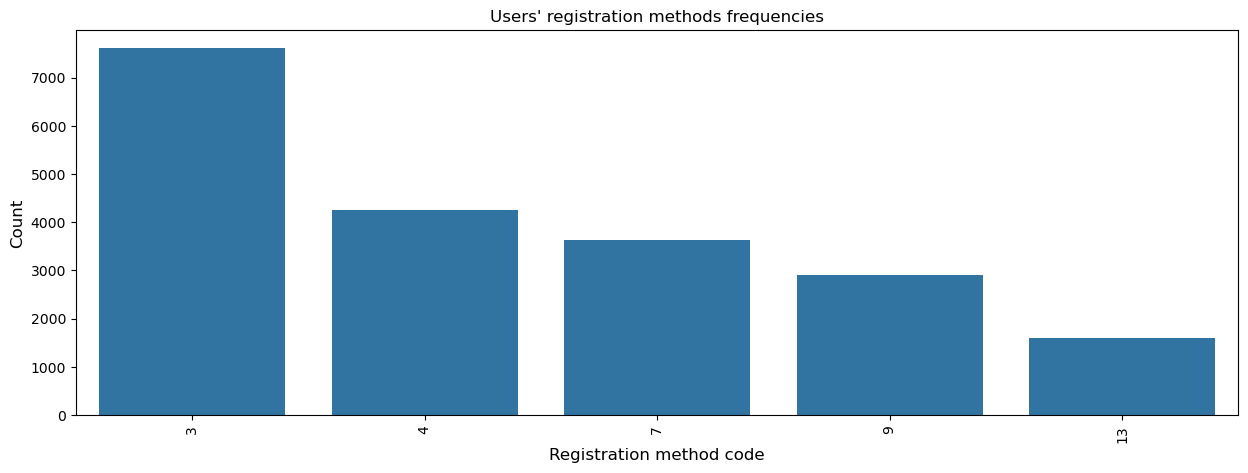

In [28]:
import seaborn as sns
# Registration method count
city_order = sorted(members["registered_via"].unique())

plt.figure(figsize=(15,5))
sns.countplot(x="registered_via", data=members, order=city_order)
plt.ylabel("Count", fontsize=12)
plt.xlabel("Registration method code", fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Users' registration methods frequencies", fontsize=12)
plt.show()

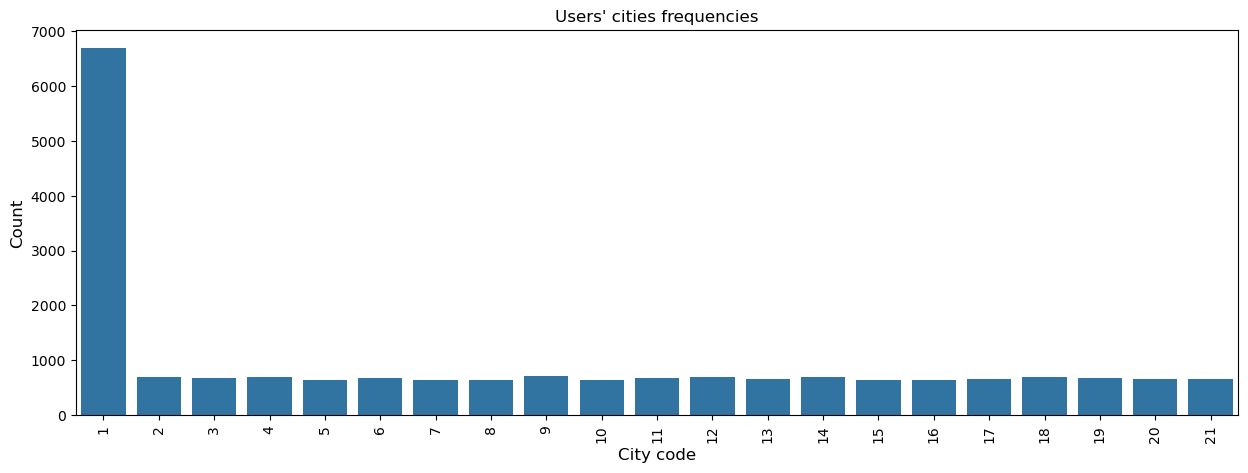

In [29]:
# City count
city_order = sorted(members['city'].unique())

plt.figure(figsize=(15,5))
sns.countplot(x="city", data=members, order = city_order)
plt.ylabel("Count", fontsize=12)
plt.xlabel("City code", fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Users' cities frequencies", fontsize=12)
plt.show()

## 5. Drop Unreliable Columns

`gender` and `bd` (age) are dropped: in the real dataset both have very high rates of
missing or garbage values (documented in the competition data notes — negative ages,
ages in the thousands, etc.), so they're excluded rather than imputed.

In [10]:
dataset_train_v2 = dataset_train.drop(columns=[
    'msno', 'gender', 'bd', 'registration_init_time', 'transaction_date',
    'membership_expire_date', 'date'
])
dataset_train_v2.dtypes

is_churn                   int64
city                       int64
registered_via             int64
payment_method_id          int64
payment_plan_days          int64
plan_list_price            int64
actual_amount_paid         int64
is_auto_renew              int64
is_cancel                  int64
num_unq                    int64
total_secs                 int64
percent_25               float64
percent_50               float64
percent_100              float64
registration_day           int64
transaction_day            int64
membership_expire_day      int64
last_play_day              int64
dtype: object

## 6. Handle Missing Values

In [11]:
# check the number of missing values in each column
dataset_train_v2.isna().sum()

is_churn                 0
city                     0
registered_via           0
payment_method_id        0
payment_plan_days        0
plan_list_price          0
actual_amount_paid       0
is_auto_renew            0
is_cancel                0
num_unq                  0
total_secs               0
percent_25               0
percent_50               0
percent_100              0
registration_day         0
transaction_day          0
membership_expire_day    0
last_play_day            0
dtype: int64

In [12]:
# Handle missing value of part of numeric/categorical columns by using mode
def replacemode(col):
    dataset_train_v2[col] = dataset_train_v2[col].fillna(dataset_train_v2[col].value_counts().index[0])

for col in ['city', 'registered_via', 'payment_method_id', 'payment_plan_days', 'is_auto_renew', 'is_cancel']:
    replacemode(col)

In [13]:
# Handle missing value of part of numeric columns by using mean
from sklearn.impute import SimpleImputer
mean_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

def replacemean(col):
    dataset_train_v2[col] = mean_imputer.fit_transform(dataset_train_v2[[col]])

for col in ['plan_list_price', 'actual_amount_paid', 'num_unq', 'total_secs',
            'percent_25', 'percent_50', 'percent_100',
            'registration_day', 'transaction_day', 'membership_expire_day', 'last_play_day']:
    replacemean(col)

dataset_train_v2.isna().sum()

is_churn                 0
city                     0
registered_via           0
payment_method_id        0
payment_plan_days        0
plan_list_price          0
actual_amount_paid       0
is_auto_renew            0
is_cancel                0
num_unq                  0
total_secs               0
percent_25               0
percent_50               0
percent_100              0
registration_day         0
transaction_day          0
membership_expire_day    0
last_play_day            0
dtype: int64

## 7. Cap Outliers (3-sigma winsorizing)

In [14]:
# Handle outliers by using capping
# NOTE: original used df[col][mask] = value (chained assignment, deprecated in modern
# pandas) -> use .loc[mask, col] = value instead, which is the correct, non-chained form
def replaceoutlier(col):
    mean, std = np.mean(dataset_train_v2[col]), np.std(dataset_train_v2[col])
    cut_off = std * 3
    lower, upper = mean - cut_off, mean + cut_off
    dataset_train_v2.loc[dataset_train_v2[col] < lower, col] = lower
    dataset_train_v2.loc[dataset_train_v2[col] > upper, col] = upper

for col in ['plan_list_price', 'actual_amount_paid', 'num_unq', 'total_secs',
            'percent_25', 'percent_50', 'percent_100',
            'registration_day', 'transaction_day', 'membership_expire_day', 'last_play_day']:
    replaceoutlier(col)

dataset_train_v2.describe()

,is_churn,city,registered_via,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,num_unq,total_secs,percent_25,percent_50,percent_100,registration_day,transaction_day,membership_expire_day,last_play_day
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,0.085123,8.026501,5.391086,39.464565,185.982734,718.915680,709.521984,0.784983,0.006023,20.619354,131743.135113,0.149966,0.101899,0.673107,777.720137,777.720137,353.633352,411.716407
std,0.279093,6.880426,2.938464,2.241494,137.240529,480.176165,473.601607,0.410875,0.077381,6.242752,62480.063939,0.017885,0.014836,0.023554,221.667432,221.667432,96.225389,1.227899
min,0.000000,1.000000,3.000000,31.000000,30.000000,149.000000,119.000000,0.000000,0.000000,7.000000,13311.000000,0.094622,0.056157,0.599749,470.000000,470.000000,43.322996,411.000000
25%,0.000000,1.000000,3.000000,39.000000,90.000000,399.000000,399.000000,1.000000,0.000000,14.000000,43407.000000,0.139394,0.093318,0.660537,575.000000,575.000000,344.000000,411.000000
50%,0.000000,6.000000,4.000000,40.000000,180.000000,699.000000,699.000000,1.000000,0.000000,23.000000,162551.000000,0.149834,0.101604,0.673575,741.000000,741.000000,390.000000,411.000000
75%,0.000000,14.000000,7.000000,41.000000,180.000000,699.000000,699.000000,1.000000,0.000000,25.000000,176454.000000,0.160045,0.110000,0.686450,959.000000,959.000000,402.000000,412.000000
max,1.000000,21.000000,13.000000,41.000000,410.000000,1499.000000,1499.000000,1.000000,1.000000,38.000000,217845.000000,0.205397,0.147803,0.746374,1230.000000,1230.000000,440.000000,416.244012


## 8. Target-Mean Encode Categorical Features

`city`, `registered_via`, and `payment_method_id` are high-cardinality categorical
codes. Rather than one-hot encoding them, each is replaced with its historical churn
rate — a form of target encoding.

In [25]:
# convert categorical variables into string first (so groupby treats them as categories, not numbers)
cat_cols = ['city', 'registered_via', 'payment_method_id']
dataset_train_v2[cat_cols] = dataset_train_v2[cat_cols].astype(str)

# replace discrete features with historical churn rate
city_mean = dataset_train_v2.groupby('city')['is_churn'].mean().reset_index(name='city_mean')
register_mean = dataset_train_v2.groupby('registered_via')['is_churn'].mean().reset_index(name='register_mean')
payment_mean = dataset_train_v2.groupby('payment_method_id')['is_churn'].mean().reset_index(name='payment_mean')

dataset_train_v3 = (dataset_train_v2
    .merge(city_mean, on='city', how='left')
    .merge(register_mean, on='registered_via', how='left')
    .merge(payment_mean, on='payment_method_id', how='left')
    .drop(columns=['city', 'registered_via', 'payment_method_id']))

dataset_train_v3.head()

,is_churn,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,num_unq,total_secs,percent_25,percent_50,percent_100,registration_day,transaction_day,membership_expire_day,last_play_day,city_mean,register_mean,payment_mean
0,0,90,399.0,399.0,1,0,32.0,194159.0,0.147191,0.110112,0.658427,470.0,470.0,350.0,411.000000,0.091954,0.185874,0.079663
1,0,180,699.0,699.0,1,0,27.0,166853.0,0.142151,0.105068,0.684796,530.0,530.0,260.0,411.000000,0.088358,0.057307,0.104167
2,1,410,1499.0,1499.0,1,0,11.0,31104.0,0.202532,0.094937,0.632911,1030.0,1030.0,440.0,411.000000,0.080247,0.101578,0.074560
3,0,90,399.0,399.0,0,0,14.0,32101.0,0.144578,0.147803,0.632530,501.0,501.0,348.0,416.244012,0.080645,0.185874,0.104167
4,0,180,699.0,699.0,1,0,23.0,161509.0,0.165796,0.091384,0.661880,1100.0,1100.0,260.0,411.000000,0.080645,0.057307,0.074560


## 9. Feature Scaling

In [16]:
# Feature Scaling for modelling purpose by using min-max-scaling
from sklearn.preprocessing import MinMaxScaler

X = dataset_train_v3.drop(columns=['is_churn'])
Y = dataset_train_v3['is_churn']

nm_X = pd.DataFrame(MinMaxScaler().fit_transform(X))
nm_X.columns = X.columns.values
nm_X.index = X.index.values
nm_X.head()

,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,num_unq,total_secs,percent_25,percent_50,percent_100,registration_day,transaction_day,membership_expire_day,last_play_day,city_mean,register_mean,payment_mean
0,0.157895,0.185185,0.202899,1.0,0.0,0.806452,0.884195,0.474558,0.588735,0.400188,0.000000,0.000000,0.773115,0.0,0.580295,1.000000,0.067643
1,0.394737,0.407407,0.420290,1.0,0.0,0.645161,0.750692,0.429059,0.533693,0.580028,0.078947,0.078947,0.546230,0.0,0.533527,0.043948,0.392456
2,1.000000,1.000000,1.000000,1.0,0.0,0.129032,0.086993,0.974135,0.423144,0.226169,0.736842,0.736842,1.000000,0.0,0.428030,0.373159,0.000000
3,0.157895,0.185185,0.202899,0.0,0.0,0.225806,0.091867,0.450973,1.000000,0.223569,0.040789,0.040789,0.768073,1.0,0.433209,1.000000,0.392456
4,0.394737,0.407407,0.420290,1.0,0.0,0.516129,0.724564,0.642514,0.384376,0.423737,0.828947,0.828947,0.546230,0.0,0.433209,0.043948,0.000000


## 10. Feature Selection

Binary flags (`is_auto_renew`, `is_cancel`) are tested with chi-squared; continuous
features are tested with an ANOVA F-test. Only features with p ≤ 0.05 against the
churn target are kept.

In [17]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

nm_col = ['is_auto_renew', 'is_cancel']
nm_X_v2 = nm_X.drop(columns=nm_col)     # continuous features
nm_X_v3 = pd.DataFrame(nm_X, columns=nm_col)  # binary features

nm_X_v4 = pd.DataFrame(
    SelectKBest(score_func=chi2, k='all').fit(nm_X_v3, Y).pvalues_ <= 0.05,
    columns=['importance'])
nm_X_v4.index = nm_X_v3.columns.values

nm_X_v5 = pd.DataFrame(
    SelectKBest(score_func=f_classif, k='all').fit(nm_X_v2, Y).pvalues_ <= 0.05,
    columns=['importance'])
nm_X_v5.index = nm_X_v2.columns.values

nm_X_v6 = pd.concat([nm_X_v4, nm_X_v5])
nm_selected = list(pd.Series(nm_X_v6[nm_X_v6['importance'] == 1].index.values))
nm_X_v7 = pd.DataFrame(nm_X, columns=nm_selected)

print('Selected features:', nm_selected)

Selected features: ['is_auto_renew', 'is_cancel', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'num_unq', 'total_secs', 'percent_25', 'membership_expire_day', 'last_play_day', 'city_mean', 'register_mean', 'payment_mean']


## 11. Dimension Reduction (PCA)

In [18]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit_transform(nm_X_v7)
print('Cumulative explained variance:')
print(np.round(np.cumsum(pca.explained_variance_ratio_), 3))

nm_X_v8 = PCA(n_components=10).fit_transform(nm_X_v7)

Cumulative explained variance:
[0.394 0.66  0.751 0.803 0.849 0.892 0.932 0.963 0.989 0.995 0.999 1.
 1.   ]


## 12. Train / Test Split

In [19]:
from sklearn.model_selection import train_test_split

nm_X_train, nm_X_test, nm_Y_train, nm_Y_test = train_test_split(
    nm_X_v8, Y, test_size=0.3, random_state=0)

print(f"train: {nm_X_train.shape}, test: {nm_X_test.shape}, churn rate train: {nm_Y_train.mean():.3f}")

train: (3486, 10), test: (1495, 10), churn rate train: 0.084


## 13. Model Comparison

10-fold cross-validated log-loss across a battery of classifiers and ensembles.

**Compatibility fix:** `BaggingClassifier`/`AdaBoostClassifier` renamed their base-model
argument from `base_estimator` to `estimator` in scikit-learn 1.2+ — updated below.

**Robustness fix:** the original loop had no error handling, so a single model's
numerical failure (e.g. QDA hitting a singular covariance matrix, a real and fairly
common edge case with correlated features) would kill the whole cell. Wrapped in
try/except so one failure doesn't block the rest.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier,
                               RandomForestClassifier, ExtraTreesClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

nm_models = [
    ('KNN', KNeighborsClassifier()),
    ('LR', LogisticRegression()),
    ('LDA', LinearDiscriminantAnalysis()),
    ('QDA', QuadraticDiscriminantAnalysis()),
    ('CART', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    # ('Linear SVM', SVC(kernel='linear')),
    # ('Kernel SVM', SVC(kernel='rbf')),
]

ensembles = [
    ('BC', BaggingClassifier(estimator=LogisticRegression())),
    ('AB', AdaBoostClassifier(estimator=LogisticRegression())),
    ('GBM', GradientBoostingClassifier()),
    ('RF', RandomForestClassifier()),
    ('ET', ExtraTreesClassifier()),
    ('XGB', XGBClassifier()),
]

In [21]:
results, names = [], []
for name, model in nm_models:
    try:
        cv_results = cross_val_score(model, nm_X_train, nm_Y_train, cv=10,
                                      scoring='neg_log_loss', n_jobs=-1, error_score='raise')
        results.append(cv_results)
        names.append(name)
        print(f"{name}: {cv_results.mean():.6f} ({cv_results.std():.6f})")
    except Exception as e:
        print(f"{name}: FAILED - {type(e).__name__}: {str(e)[:120]}")

KNN: -1.196488 (0.212942)
LR: -0.163741 (0.005093)
LDA: -0.206129 (0.012138)
QDA: -0.245311 (0.041498)
CART: -3.236219 (0.369477)
NB: -0.291767 (0.030072)


CART: -2.987612 (0.525052)
NB: -0.291325 (0.030077)


In [22]:
results2, names2 = [], []
for name2, model2 in ensembles:
    try:
        cv_results2 = cross_val_score(model2, nm_X_train, nm_Y_train, cv=10,
                                       scoring='neg_log_loss', n_jobs=-1, error_score='raise')
        results2.append(cv_results2)
        names2.append(name2)
        print(f"{name2}: {cv_results2.mean():.6f} ({cv_results2.std():.6f})")
    except Exception as e:
        print(f"{name2}: FAILED - {type(e).__name__}: {str(e)[:120]}")

BC: -0.164234 (0.005682)
AB: -0.423609 (0.014988)
GBM: -0.159764 (0.010455)
RF: -0.177373 (0.041717)
ET: -0.159376 (0.012858)
XGB: -0.141602 (0.015551)


AB: -0.429469 (0.011853)


GBM: -0.147691 (0.013931)


RF: -0.168627 (0.043776)


ET: -0.170224 (0.040024)


XGB: -0.123861 (0.017985)


## 14. Hyperparameter Tuning: XGBoost

In [23]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "learning_rate": [0.1],
    "min_child_weight": [1],
    "max_depth": [9],
    "gamma": [0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "objective": ['binary:logistic'],
}
grid_search_XGB = GridSearchCV(estimator=XGBClassifier(), param_grid=parameters,
                                scoring="neg_log_loss", cv=10, n_jobs=-1)
grid_result_XGB = grid_search_XGB.fit(nm_X_train, nm_Y_train)
print(f"Best: {grid_result_XGB.best_score_:.6f} using {grid_result_XGB.best_params_}")

Best: -0.139808 using {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'objective': 'binary:logistic', 'subsample': 0.8}


## 15. Final Evaluation on Held-Out Test Set

In [24]:
from sklearn.metrics import log_loss

nm_Y_predict = grid_result_XGB.predict_proba(nm_X_test)
logloss = log_loss(nm_Y_test, nm_Y_predict)
print(f"Log Loss Score: {logloss}")

Log Loss Score: 0.12226740388171671
